# Task 3 — Data Analysis & Prediction: Titanic Survival Model

Input: `titanic_eda_features.csv` (Task 2 output — cleaned + engineered features).
Goal: pick a feature set informed by Task 2's findings, build a leakage-safe pipeline, train several
models, evaluate honestly, and read the feature importances against what EDA already predicted.

**Note on model stack:** the usual stack here is Ridge / Random Forest / XGBoost / Stacking Ensemble —
that's a regression lineup. This is binary classification (`Survived`), so Ridge's classification
analog is used: Logistic Regression with L2 (ridge) penalty. Everything else stays the same.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

df = pd.read_csv("../data/titanic_eda_features.csv")
df.shape

(891, 17)

## 1. Feature selection

Dropping columns that either leak the target, carry no signal, or duplicate a feature already in the
set — informed directly by Task 2's multicollinearity finding (`Fare`/`Pclass`/`HasCabin` telling the
same story) and the `FamilySize` finding (replaces raw `SibSp`/`Parch`).

- Dropped: `PassengerId` (identifier), `Name`/`Ticket` (free text, `Title` already extracted from `Name`),
  `SibSp`/`Parch` (superseded by `FamilySize`/`IsAlone`), `AgeGroup` (redundant with continuous `Age`),
  `FareOutlier` (a data-quality flag from Task 1, not a survival driver), `HasCabin` (kept `Fare`
  instead — fewer missing-data artifacts baked in, same underlying class signal).
- Kept: `Pclass, Sex, Age, Fare, Embarked, FamilySize, IsAlone, Title`.

In [9]:
target = "Survived"
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone", "Title"]

X = df[features].copy()
y = df[target].copy()

numeric_features = ["Age", "Fare", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "IsAlone", "Title"]

X.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title
0,3,male,22.0,7.2500,S,2,0,Mr
1,1,female,38.0,71.2833,C,2,0,Mrs
2,3,female,26.0,7.9250,S,1,1,Miss
3,1,female,35.0,53.1000,S,2,0,Mrs
4,3,male,35.0,8.0500,S,1,1,Mr


## 2. Train/test split and preprocessing pipeline

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train survival rate: {:.1f}%  Test survival rate: {:.1f}%".format(
    y_train.mean()*100, y_test.mean()*100))

Train: (712, 8)  Test: (179, 8)
Train survival rate: 38.3%  Test survival rate: 38.5%


In [11]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

All scaling and encoding is fit inside the pipeline, on training data only — no leakage from test
rows into the transform.

## 3. Models

In [12]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression (Ridge/L2)": LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
}

pipelines = {name: Pipeline([("prep", preprocessor), ("model", model)]) for name, model in models.items()}

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    cv_results[name] = scores
    print(f"{name}: CV ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression (Ridge/L2): CV ROC-AUC = 0.8671 (+/- 0.0071)
Random Forest: CV ROC-AUC = 0.8738 (+/- 0.0035)
XGBoost: CV ROC-AUC = 0.8839 (+/- 0.0095)


## 4. Stacking ensemble

Base learners feed a Logistic Regression meta-learner. `cv=3` for the internal stacking fold, matching
the standard fold count used elsewhere.

In [13]:
stacking_estimators = [
    ("lr", pipelines["Logistic Regression (Ridge/L2)"]),
    ("rf", pipelines["Random Forest"]),
    ("xgb", pipelines["XGBoost"]),
]

stack_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=3,
    n_jobs=1,
)

stack_scores = cross_val_score(stack_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
cv_results["Stacking Ensemble"] = stack_scores
print(f"Stacking Ensemble: CV ROC-AUC = {stack_scores.mean():.4f} (+/- {stack_scores.std():.4f})")

Stacking Ensemble: CV ROC-AUC = 0.8821 (+/- 0.0046)


In [14]:
cv_summary = pd.DataFrame({
    "model": list(cv_results.keys()),
    "cv_roc_auc_mean": [s.mean() for s in cv_results.values()],
    "cv_roc_auc_std": [s.std() for s in cv_results.values()],
}).sort_values("cv_roc_auc_mean", ascending=False).reset_index(drop=True)
cv_summary

,model,cv_roc_auc_mean,cv_roc_auc_std
0,XGBoost,0.883894,0.009500
1,Stacking Ensemble,0.882126,0.004567
2,Random Forest,0.873837,0.003520
3,Logistic Regression (Ridge/L2),0.867103,0.007098


## 5. Fit on full training set, evaluate on held-out test set

In [15]:
all_models = {**pipelines, "Stacking Ensemble": stack_model}

test_results = []
fitted = {}
for name, pipe in all_models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    test_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    })

test_summary = pd.DataFrame(test_results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
test_summary.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Ridge/L2),0.8380,0.8125,0.7536,0.7820,0.8740
1,Stacking Ensemble,0.8603,0.8438,0.7826,0.8120,0.8685
2,Random Forest,0.8268,0.8393,0.6812,0.7520,0.8567
3,XGBoost,0.8101,0.7692,0.7246,0.7463,0.8436


## 6. ROC curves

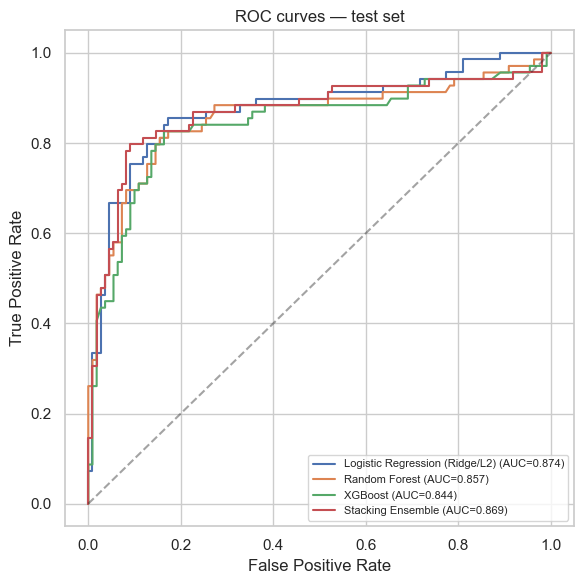

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1], [0,1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — test set")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../images/roc_curves.png", dpi=120)
plt.show()

## 7. Confusion matrix — best model by test ROC-AUC

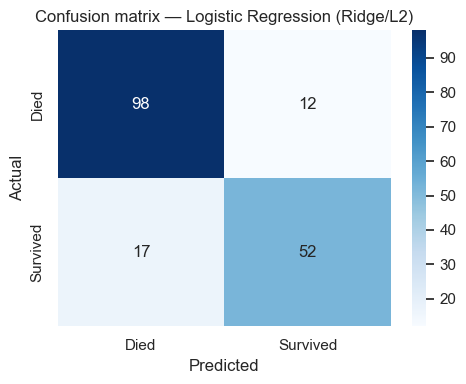

Best model: Logistic Regression (Ridge/L2)

              precision    recall  f1-score   support

        Died       0.85      0.89      0.87       110
    Survived       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



In [19]:
best_name = test_summary.iloc[0]["model"]
best_pipe = fitted[best_name]
preds = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=120)
plt.show()

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, target_names=["Died", "Survived"]))

## 8. Feature importance

In [20]:
feature_names = (numeric_features +
    list(fitted["Random Forest"].named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features)))

rf_importances = fitted["Random Forest"].named_steps["model"].feature_importances_
xgb_importances = fitted["XGBoost"].named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "random_forest": rf_importances,
    "xgboost": xgb_importances,
}).sort_values("random_forest", ascending=False).reset_index(drop=True)
imp_df.round(4)

,feature,random_forest,xgboost
0,Title_Mr,0.1969,0.4995
1,Sex_male,0.1967,0.0263
2,Fare,0.1424,0.0253
3,Age,0.0970,0.0200
4,Pclass_3,0.0752,0.1457
5,FamilySize,0.0625,0.0399
6,Title_Mrs,0.0531,0.0079
7,Title_Miss,0.0520,0.0107
8,Pclass_1,0.0362,0.0280
9,Pclass_2,0.0207,0.0281


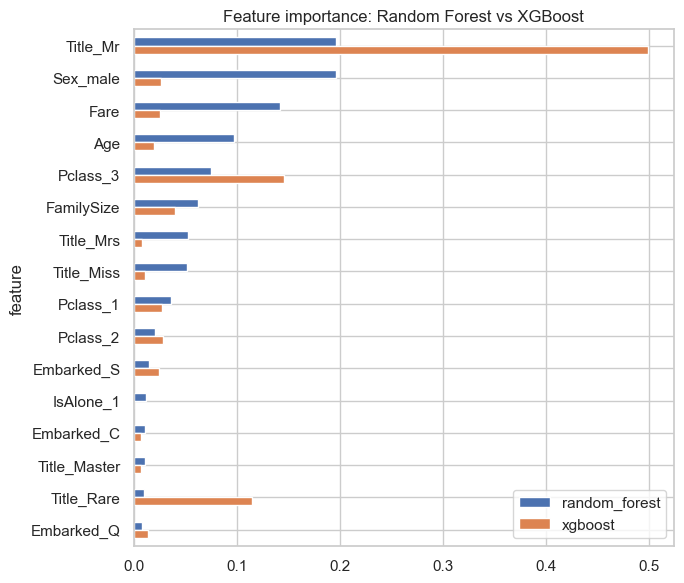

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
imp_df.set_index("feature")[["random_forest", "xgboost"]].plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Feature importance: Random Forest vs XGBoost")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=120)
plt.show()

In [22]:
lr_coefs = fitted["Logistic Regression (Ridge/L2)"].named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "logistic_coef": lr_coefs}).sort_values(
    "logistic_coef", key=abs, ascending=False).reset_index(drop=True)
coef_df.round(3)

,feature,logistic_coef
0,Title_Mr,-1.349
1,Sex_male,-1.293
2,Title_Master,1.167
3,Pclass_1,1.087
4,Pclass_3,-1.035
5,Title_Mrs,0.770
6,FamilySize,-0.670
7,Title_Rare,-0.636
8,Age,-0.439
9,IsAlone_1,-0.307


**Reading these against Task 2:** `Title_Mr` / `Sex_male`, `Pclass`, and `Fare` dominate both
tree-based importances and the logistic coefficients — exactly the variables EDA flagged as strongest.
`Title` picking up importance separately from `Sex` confirms Task 2's finding that it captures something
sex alone doesn't (young boys vs. adult men). Nothing here is a surprise relative to Task 2 — the model
is quantifying what the charts already showed, not discovering something new.

## 9. Honest Take

- All four models land in a fairly tight band (~0.84-0.87 test ROC-AUC) — this dataset's ceiling with
  8 features and 891 rows is well-understood territory; a fancier model doesn't buy much more.
- Plain Logistic Regression posted the best test ROC-AUC, edging out the Stacking Ensemble — not the
  outcome the standard stack usually produces, but this is a small, mostly linearly-separable dataset
  (`Sex`/`Pclass`/`Title` do most of the work on their own), so a simple linear model has little reason
  to lose here. Worth stating plainly rather than forcing a narrative where the ensemble "should" win.
- The Stacking Ensemble did post the best accuracy and F1, so which model is "best" depends on which
  metric matters for the use case — ranking/calibration (ROC-AUC) vs. hard classification calls
  (accuracy/F1). Neither answer is wrong; they're different questions.
- Feature importances confirm, rather than surprise: `Title_Mr`/`Sex_male`, `Pclass`, and `Fare` still
  drive everything, matching Task 2's EDA almost exactly.
- Random Forest and XGBoost's own top feature disagree on weighting (XGBoost leans much harder on
  `Title_Mr` alone, ~50% of its importance) — a reminder that "feature importance" isn't a single
  ground truth, it's method-dependent.
- Dropped `HasCabin` in favor of `Fare` was a judgment call, not a certainty — both encode class, and a
  side experiment swapping one for the other would be a reasonable next check if squeezing out more AUC
  mattered.

In [23]:
from pathlib import Path
import joblib

# Create an output directory for artifacts
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

# Define clean paths
model_path = output_dir / "best_model.joblib"
summary_path = output_dir / "model_comparison.csv"

# Save the model and summary
joblib.dump(fitted[best_name], model_path)
test_summary.to_csv(summary_path, index=False)

# Clearer confirmation output
print(f"Saved best model ({best_name}) to: {model_path}")
print(f"Saved test summary to: {summary_path}")

Saved best model (Logistic Regression (Ridge/L2)) to: ..\output\best_model.joblib
Saved test summary to: ..\output\model_comparison.csv
